# 电商用户行为分析与RFM用户分层项目

本项目基于英国电商交易数据，对用户购买行为进行分析，
包括用户活跃时间、消费行为、销售表现以及基于RFM模型的用户分层，
用于识别高价值用户并提供运营决策支持。

## 数据读取与初步探索

- 数据包含用户订单记录
- 每一行代表一次购买行为
- 主要字段包括：用户ID、商品、数量、价格、时间等

In [27]:
import pandas as pd
df = pd.read_csv('online_retail_II.csv', encoding='ISO-8859-1')
display(df.head())
print("\n原始数据形状:（行数，列数）",df.shape)
df.info()
df.describe()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom



原始数据形状:（行数，列数） (1067371, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


## 数据清洗（1）：数据质量检查

本部分主要进行数据初步检查，包括：
- 缺失值统计
- 字段名称标准化（CustomerID）
- 数据整体规模查看
- 退货订单初步识别（Quantity < 0）

In [28]:
print("\n缺失值统计:")
print(df.isnull().sum())
df = df.rename(columns={'Customer ID':'CustomerID'}) 
print("列名重命名后：")
print(df.columns.tolist())
df = df.dropna(subset=['CustomerID'])
print("\n初步清洗不存在用户数据形状:（行数，列数）",df.shape)
refund_count = (df['Quantity'] < 0).sum()
df[df['Quantity'] < 0].head()


缺失值统计:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64
列名重命名后：
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID', 'Country']

初步清洗不存在用户数据形状:（行数，列数） (824364, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


# 退货数据统计
total_orders = len(df)
return_orders = len(df[df['Quantity'] < 0])

print("总订单数:", total_orders)
print("退货订单数:", return_orders)
print("退货率:", return_orders / total_orders)

# 只保留正常购买订单
df = df[df['Quantity'] > 0]

# 清洗后数据规模
df.shape

In [29]:
total_count = len(df)
print("\n商品退货总数:", refund_count)
print("\n商品交易总数：", total_count)
print("\n商品退货率:", refund_count / total_count)
df = df[df['Quantity'] > 0]
print("\n初步清洗退货数据形状:（行数，列数）",df.shape)


商品退货总数: 18744

商品交易总数： 824364

商品退货率: 0.022737528567477475

初步清洗退货数据形状:（行数，列数） (805620, 8)


## 时间字段处理

- 将 InvoiceDate 转换为 datetime 格式
- 提取年、月、日、小时信息
- 用于分析用户购买时间规律

In [32]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['year'] = df['InvoiceDate'].dt.year
df['month'] = df['InvoiceDate'].dt.month
df['day'] = df['InvoiceDate'].dt.day
df['hour'] = df['InvoiceDate'].dt.hour
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,year,month,day,hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009,12,1,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,1,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,1,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009,12,1,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009,12,1,7


## 用户行为时间分析（小时维度）

- 基于订单时间提取小时字段
- 分析用户在一天中的活跃分布
- 识别用户活跃高峰时段

In [35]:
hourly = df.groupby('hour')['Invoice'].nunique()
hourly

hour
6        1
7       76
8      979
9     2549
10    4364
11    4609
12    6170
13    5419
14    4561
15    3994
16    2306
17    1158
18     415
19     324
20      51
Name: Invoice, dtype: int64

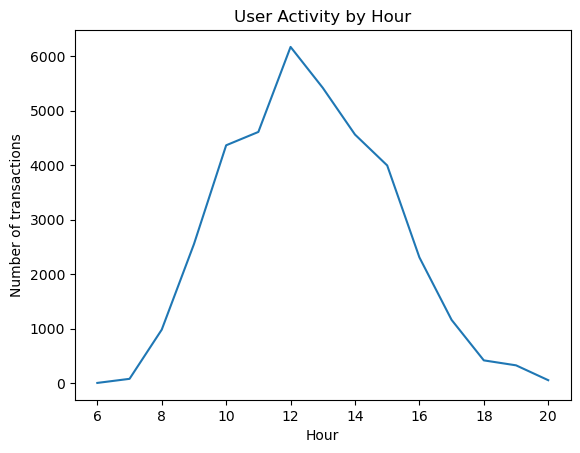

In [36]:
import matplotlib.pyplot as plt

hourly.plot()
plt.title('User Activity by Hour')
plt.xlabel('Hour')
plt.ylabel('Number of transactions')
plt.show()

## 用户活跃时间分析

用户在中午（12点左右）达到峰值，
说明用户更倾向于在碎片时间（如午休）进行浏览或购物。

## 每小时销售额分析

销售额走势与订单量基本一致，
说明销售主要由订单数量驱动，而非客单价变化。

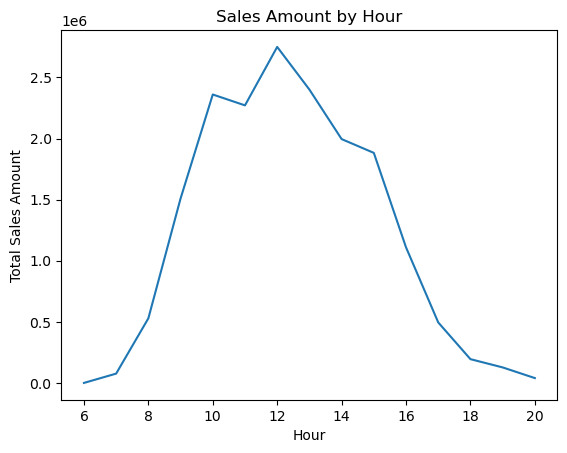

In [38]:
df['TotalAmount'] = df['Quantity'] * df['Price']

hourly_sales = df.groupby('hour')['TotalAmount'].sum()

hourly_sales.plot()
plt.title('Sales Amount by Hour')
plt.xlabel('Hour')
plt.ylabel('Total Sales Amount')
plt.show()

## 客单价分析（AOV）

不同时间段客单价波动较大，
部分时间点由于订单数量少，导致AOV异常偏高（统计偏差）。

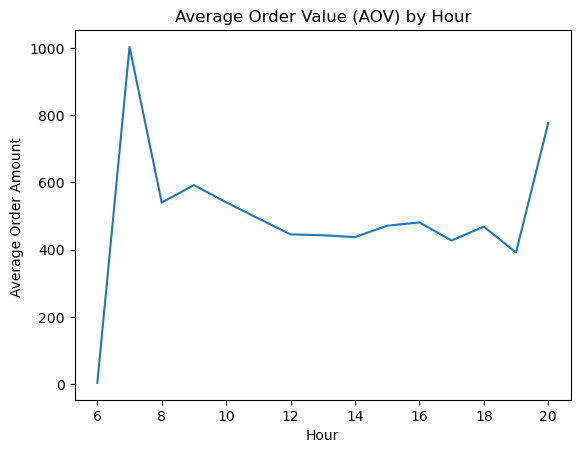

In [39]:
hourly_orders = df.groupby('hour')['Invoice'].nunique()
hourly_sales = df.groupby('hour')['TotalAmount'].sum()

hourly_aov = hourly_sales / hourly_orders

hourly_aov.plot()
plt.title('Average Order Value (AOV) by Hour')
plt.xlabel('Hour')
plt.ylabel('Average Order Amount ')
plt.show()

## 用户消费行为分析（Customer Analysis）

### 分析目的
分析不同用户的购买频率和消费金额，识别高价值用户群体。

### 分析方法
按 CustomerID 分组，统计：
- 订单数量（Invoice）
- 总消费金额（TotalAmount）

### 初步发现
- 不同用户之间消费差异明显
- 存在少数高消费用户（如 CustomerID 12346），贡献了较高销售额
- 大部分用户订单数较少，属于长尾用户

### 业务启示
- 应重点维护高价值用户（VIP客户）
- 可以针对高消费用户推出会员制度或专属优惠
- 对低频用户进行促活（如优惠券、推荐机制）

In [40]:
customer_stats = df.groupby('CustomerID').agg({
    'Invoice': 'nunique',       
    'TotalAmount': 'sum'         
})

customer_stats.head()

,Invoice,TotalAmount
CustomerID,,
12346.0,12,77556.46
12347.0,8,5633.32
12348.0,5,2019.40
12349.0,4,4428.69
12350.0,1,334.40


In [41]:
top10 = customer_stats.sort_values(by='TotalAmount', ascending=False).head(10)
top10

,Invoice,TotalAmount
CustomerID,,
18102.0,145,608821.65
14646.0,152,528602.52
14156.0,156,313946.37
14911.0,398,295972.63
17450.0,51,246973.09
13694.0,143,196482.81
17511.0,60,175603.55
16446.0,2,168472.50
16684.0,55,147142.77


### 用户消费金额分布分析

从用户消费金额分布来看，数据呈现明显的右偏分布（长尾分布）特征。

大部分用户的消费金额集中在较低区间（0–10000），仅有少数用户消费金额显著高于平均水平。

说明平台收入主要依赖少数高价值用户，而大部分用户贡献较低，呈现典型的“二八分布”特征。

### 业务启示

- 应重点识别并维护高价值用户（VIP用户）
- 可针对高消费用户提供专属服务或会员体系
- 对低消费用户进行促活与转化（如优惠券、推荐机制）

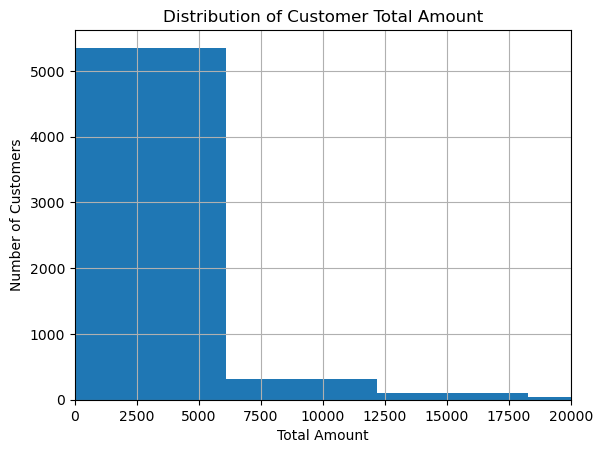

In [42]:
import matplotlib.pyplot as plt

customer_stats['TotalAmount'].hist(bins=100)

plt.xlim(0, 20000)
plt.title('Distribution of Customer Total Amount')
plt.xlabel('Total Amount')
plt.ylabel('Number of Customers')

plt.show()

In [43]:
customer_stats['TotalAmount'].describe()
df['InvoiceDate'].max()

Timestamp('2011-12-09 12:50:00')

## RFM模型

- Recency：最近一次购买时间
- Frequency：购买频率
- Monetary：消费金额

In [47]:
customer_r = df.groupby('CustomerID')['InvoiceDate'].max()
customer_r
reference_date = df['InvoiceDate'].max()
customer_r = (reference_date - customer_r).dt.days
customer_r.head()




CustomerID
12346.0    325
12347.0      1
12348.0     74
12349.0     18
12350.0    309
Name: InvoiceDate, dtype: int64

In [48]:
customer_f = df.groupby('CustomerID')['Invoice'].nunique()
customer_f.head()

CustomerID
12346.0    12
12347.0     8
12348.0     5
12349.0     4
12350.0     1
Name: Invoice, dtype: int64

In [49]:
customer_m = df.groupby('CustomerID')['TotalAmount'].sum()
customer_m.head()

CustomerID
12346.0    77556.46
12347.0     5633.32
12348.0     2019.40
12349.0     4428.69
12350.0      334.40
Name: TotalAmount, dtype: float64

In [51]:
rfm = pd.concat([customer_r, customer_f, customer_m], axis=1)
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,12,77556.46
12347.0,1,8,5633.32
12348.0,74,5,2019.40
12349.0,18,4,4428.69
12350.0,309,1,334.40


In [52]:
rfm.shape

(5881, 3)

In [54]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])
rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm['RFM_score']

CustomerID
12346.0    255
12347.0    545
12348.0    344
12349.0    535
12350.0    212
          ... 
18283.0    554
18284.0    122
18285.0    122
18286.0    134
18287.0    445
Name: RFM_score, Length: 5881, dtype: object

In [55]:
rfm['RFM_score'].value_counts(normalize=True).head(10)

RFM_score
555    0.080599
111    0.054413
455    0.042340
121    0.028737
344    0.028397
211    0.027546
444    0.024996
112    0.024826
544    0.022785
122    0.022615
Name: proportion, dtype: float64

## 用户分群

基于RFM模型，将用户分为：
- 核心用户
- 重要用户
- 普通用户
- 流失用户

In [56]:
def segment(row):
    r = int(row['R_score'])
    f = int(row['F_score'])
    m = int(row['M_score'])
    
    if row['RFM_score'] == '555':
        return '核心用户'
    elif row['RFM_score'] == '111':
        return '流失用户'
    elif r >= 4 and f >= 4:
        return '重要用户'
    else:
        return '普通用户'

rfm['Segment'] = rfm.apply(segment, axis=1)

## 用户结构分析

- 普通用户占比最高（约69%）
- 重要用户约17%
- 核心用户约8%
- 流失用户约5%

说明：
平台主要收入依赖少数高价值用户，
需要重点维护核心用户，同时提升普通用户转化。

In [57]:
rfm['Segment'].value_counts(normalize=True)

Segment
普通用户    0.693590
重要用户    0.171399
核心用户    0.080599
流失用户    0.054413
Name: proportion, dtype: float64

# 总结

- 用户活跃时间集中在中午
- 销售额与订单量高度相关
- 用户消费呈长尾分布
- 少数用户贡献主要收入（RFM验证）

👉 建议：
- 午间做促销
- 重点维护高价值用户
- 激活普通用户